# Previsão de Diabetes Mellitus — CDC BRFSS 2015
## Etapa 2: Pré-processamento e Feature Engineering

---

**Objetivo:** Transformar os dados brutos em um dataset limpo, consistente e enriquecido, pronto para a etapa de modelagem.

**Decisões orientadas pela EDA:**
- Remover 24.206 duplicatas identificadas (9,54%)
- Tratar outlier extremo de BMI (valor máximo = 98)
- Renomear colunas para português
- Criar features derivadas com base nos padrões de risco observados
- Montar pipeline sklearn reutilizável para treino e inferência
- Estratégia de desbalanceamento via `class_weight='balanced'` + ajuste de threshold
- Exportar artefatos para a etapa de modelagem

**Por que não usar SMOTE?**  
O BRFSS possui 14 variáveis binárias. O SMOTE interpola entre vizinhos no espaço de features, gerando valores como 0.3 ou 0.7 para essas variáveis — sem significado clínico real. Com 229 mil registros, o problema não é falta de dados, mas proporção entre classes. A abordagem `class_weight='balanced'` é mais adequada: penaliza erros na classe minoritária sem criar dados sintéticos, preserva a integridade das variáveis binárias e é padrão em projetos clínicos com dados reais.

## 0. Instalação e Imports

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn kagglehub joblib -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base          import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor':   '#2d3248', 'axes.labelcolor': '#c9d1e0',
    'xtick.color':      '#8892a4', 'ytick.color':     '#8892a4',
    'text.color':       '#c9d1e0', 'grid.color':      '#2d3248',
    'grid.linewidth':   0.5,       'font.family':     'monospace',
    'axes.titlesize':   13,        'figure.dpi':      110,
})
CORES  = ['#4fc3f7', '#ef5350']
SEED   = 42
np.random.seed(SEED)

print('✅ Imports OK')

✅ Imports OK
✅ Imports OK


## 1. Carregamento dos Dados

In [ ]:
try:
    import kagglehub
    path    = kagglehub.dataset_download('alexteboul/diabetes-health-indicators-dataset')
    csv     = os.path.join(path, 'diabetes_binary_health_indicators_BRFSS2015.csv')
    df_raw  = pd.read_csv(csv)
    print(f'✅ Carregado via kagglehub: {df_raw.shape}')
except Exception as e:
    print(f'⚠️  kagglehub falhou ({e}) → usando URL de fallback')
    URL    = ('https://raw.githubusercontent.com/dsaks/cdc-diabetes-health-indicators/'
              'main/diabetes_binary_health_indicators_BRFSS2015.csv')
    df_raw = pd.read_csv(URL)
    print(f'✅ Carregado via URL: {df_raw.shape}')

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
✅ Carregado via kagglehub: (253680, 22)


## 2. Renomeação das Colunas
Tradução para português para facilitar leitura dos gráficos, relatórios e comunicação com stakeholders.

In [ ]:
MAPA_COLUNAS = {
    'Diabetes_binary'      : 'diabetes',
    'HighBP'               : 'pressao_alta',
    'HighChol'             : 'colesterol_alto',
    'CholCheck'            : 'checou_colesterol',
    'BMI'                  : 'imc',
    'Smoker'               : 'fumante',
    'Stroke'               : 'avc',
    'HeartDiseaseorAttack' : 'doenca_cardiaca',
    'PhysActivity'         : 'atividade_fisica',
    'Fruits'               : 'consume_frutas',
    'Veggies'              : 'consume_vegetais',
    'HvyAlcoholConsump'    : 'alcool_pesado',
    'AnyHealthcare'        : 'plano_saude',
    'NoDocbcCost'          : 'sem_medico_por_custo',
    'GenHlth'              : 'saude_geral',
    'MentHlth'             : 'dias_saude_mental_ruim',
    'PhysHlth'             : 'dias_saude_fisica_ruim',
    'DiffWalk'             : 'dificuldade_caminhar',
    'Sex'                  : 'sexo',
    'Age'                  : 'faixa_etaria',
    'Education'            : 'escolaridade',
    'Income'               : 'renda',
}

df = df_raw.rename(columns=MAPA_COLUNAS).copy()

print('✅ Colunas renomeadas:')
print(df.columns.tolist())

✅ Colunas renomeadas:
['diabetes', 'pressao_alta', 'colesterol_alto', 'checou_colesterol', 'imc', 'fumante', 'avc', 'doenca_cardiaca', 'atividade_fisica', 'consume_frutas', 'consume_vegetais', 'alcool_pesado', 'plano_saude', 'sem_medico_por_custo', 'saude_geral', 'dias_saude_mental_ruim', 'dias_saude_fisica_ruim', 'dificuldade_caminhar', 'sexo', 'faixa_etaria', 'escolaridade', 'renda']
✅ Colunas renomeadas:
['diabetes', 'pressao_alta', 'colesterol_alto', 'checou_colesterol', 'imc', 'fumante', 'avc', 'doenca_cardiaca', 'atividade_fisica', 'consume_frutas', 'consume_vegetais', 'alcool_pesado', 'plano_saude', 'sem_medico_por_custo', 'saude_geral', 'dias_saude_mental_ruim', 'dias_saude_fisica_ruim', 'dificuldade_caminhar', 'sexo', 'faixa_etaria', 'escolaridade', 'renda']


## 3. Remoção de Duplicatas
A EDA identificou 24.206 linhas duplicadas (9,54%). Como o dataset é derivado de uma survey, duplicatas representam respostas coincidentes entre entrevistados distintos — a decisão conservadora é removê-las para evitar vazamento de informação no treino.

In [ ]:
n_antes = len(df)

df = df.drop_duplicates().reset_index(drop=True)

n_depois  = len(df)
removidas = n_antes - n_depois

print(f'Antes  : {n_antes:>7,} linhas')
print(f'Depois : {n_depois:>7,} linhas')
print(f'Removidas: {removidas:,} duplicatas ({removidas/n_antes*100:.2f}%)')

Antes  : 253,680 linhas
Depois : 229,474 linhas
Removidas: 24,206 duplicatas (9.54%)


## 4. Tratamento de Outliers
A EDA identificou BMI = 98 como outlier extremo. Aplicamos Winsorização no percentil 99 para preservar a distribuição sem distorcer os modelos.

In [ ]:
# Diagnóstico antes do tratamento
print('IMC — estatísticas antes do tratamento:')
print(df['imc'].describe().round(2))
print(f'\nValores com IMC > 60: {(df["imc"] > 60).sum()}')
print(f'Valores com IMC > 70: {(df["imc"] > 70).sum()}')

IMC — estatísticas antes do tratamento:
count    229474.00
mean         28.69
std           6.79
min          12.00
25%          24.00
50%          27.00
75%          32.00
max          98.00
Name: imc, dtype: float64

Valores com IMC > 60: 805
Valores com IMC > 70: 584
IMC — estatísticas antes do tratamento:
count    229474.00
mean         28.69
std           6.79
min          12.00
25%          24.00
50%          27.00
75%          32.00
max          98.00
Name: imc, dtype: float64

Valores com IMC > 60: 805
Valores com IMC > 70: 584


Teto aplicado (p99): 50.0

IMC — estatísticas após tratamento:
count    229474.00
mean         28.57
std           6.19
min          12.00
25%          24.00
50%          27.00
75%          32.00
max          50.00
Name: imc, dtype: float64


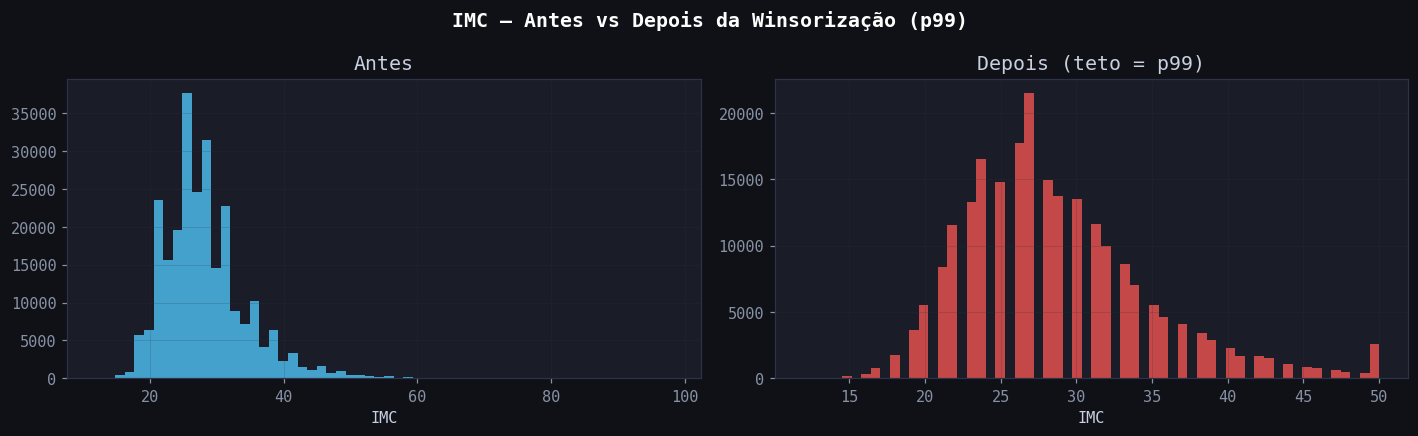

In [ ]:
# Winsorização no percentil 99 (preserva distribuição, remove extremos)
p99_imc = df['imc'].quantile(0.99)
df['imc'] = df['imc'].clip(upper=p99_imc)

print(f'Teto aplicado (p99): {p99_imc}')
print(f'\nIMC — estatísticas após tratamento:')
print(df['imc'].describe().round(2))

# Visualização antes × depois
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('IMC — Antes vs Depois da Winsorização (p99)',
             fontsize=13, fontweight='bold', color='white')

df_raw_renamed = df_raw.rename(columns=MAPA_COLUNAS)
axes[0].hist(df_raw_renamed['imc'], bins=60, color=CORES[0], alpha=0.8, edgecolor='none')
axes[0].set_title('Antes')
axes[0].set_xlabel('IMC')
axes[0].grid(True, alpha=0.25)

axes[1].hist(df['imc'], bins=60, color=CORES[1], alpha=0.8, edgecolor='none')
axes[1].set_title('Depois (teto = p99)')
axes[1].set_xlabel('IMC')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

O que o gráfico mostra bem: no painel "Antes" a distribuição tem um pico principal entre 20–30 e uma cauda longa e achatada se estendendo até 100, com barras quase invisíveis após o IMC 50, exatamente os 805 outliers acima de 60 e os 584 acima de 70 identificados no diagnóstico. No painel "Depois" a distribuição ficou limpa, com formato de sino assimétrico à direita terminando em 50, que é exatamente o p99 calculado.

## Feature Engineering
Com base nos padrões observados na EDA, criei features derivadas que capturam relações não-lineares e interações relevantes.

In [ ]:
def criar_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria features derivadas baseadas nos padrões identificados na EDA.
    Retorna novo DataFrame sem modificar o original.
    """
    d = df.copy()

    # Categoria de IMC (limiar clínico OMS)
    # EDA mostrou inflexão relevante no limiar 30 (obesidade grau I)
    d['imc_categoria'] = pd.cut(
        d['imc'],
        bins=[0, 18.5, 25, 30, 35, 100],
        labels=[0, 1, 2, 3, 4],   # abaixo peso / normal / sobrepeso / ob.I / ob.II+
        right=False
    ).astype(float)

    # Contagem de fatores de risco acumulados
    # EDA: taxa de DM sobe de 2.5% (0 fatores) para 60% (5 fatores)
    d['n_fatores_risco'] = (
        d['pressao_alta'] +
        d['colesterol_alto'] +
        (d['imc'] >= 30).astype(float) +
        d['doenca_cardiaca'] +
        d['avc']
    )

    # Interação Idade × Saúde Geral
    # Heatmap mostrou efeito combinado muito forte entre essas duas variáveis
    d['idade_x_saude_geral'] = d['faixa_etaria'] * d['saude_geral']

    # Score de comportamento saudável
    # Agrega fatores protetores identificados na EDA
    d['score_saudavel'] = (
        d['atividade_fisica'] +
        d['consume_frutas'] +
        d['consume_vegetais'] +
        (1 - d['fumante']) +          # não fumante = ponto positivo
        (1 - d['alcool_pesado'])       # sem consumo pesado = ponto positivo
    )

    # Score socioeconômico
    # Renda e escolaridade mostraram relação consistente com o risco
    d['score_socioeconomico'] = d['renda'] + d['escolaridade']

    # Flag de alto risco combinado
    # Pacientes idosos (faixa ≥ 9 = 60+ anos) com saúde ruim (≥ 4)
    d['alto_risco_combinado'] = (
        (d['faixa_etaria'] >= 9) & (d['saude_geral'] >= 4)
    ).astype(float)

    return d


df = criar_features(df)

novas = ['imc_categoria','n_fatores_risco','idade_x_saude_geral',
         'score_saudavel','score_socioeconomico','alto_risco_combinado']

print(f'✅ {len(novas)} features criadas:')
for f in novas:
    print(f'  • {f}')
print(f'\nShape final: {df.shape}')

✅ 6 features criadas:
  • imc_categoria
  • n_fatores_risco
  • idade_x_saude_geral
  • score_saudavel
  • score_socioeconomico
  • alto_risco_combinado

Shape final: (229474, 28)


In [ ]:
# Validação: taxa de DM pelas novas features
print('Taxa de DM (%) por nº de fatores de risco acumulados:')
print((df.groupby('n_fatores_risco')['diabetes'].mean() * 100).round(1).to_string())

print('\nTaxa de DM (%) por categoria de IMC:')
labels_imc = {0:'Abaixo peso', 1:'Normal', 2:'Sobrepeso', 3:'Obesidade I', 4:'Obesidade II+'}
taxa_imc_cat = df.groupby('imc_categoria')['diabetes'].mean() * 100
taxa_imc_cat.index = [labels_imc[i] for i in taxa_imc_cat.index]
print(taxa_imc_cat.round(1).to_string())

print('\nTaxa de DM (%) por flag de alto risco combinado:')
print((df.groupby('alto_risco_combinado')['diabetes'].mean() * 100).round(1).to_string())

Taxa de DM (%) por nº de fatores de risco acumulados:
n_fatores_risco
0.0     3.1
1.0     8.8
2.0    19.4
3.0    34.3
4.0    45.5
5.0    60.0

Taxa de DM (%) por categoria de IMC:
Abaixo peso       5.5
Normal            6.6
Sobrepeso        12.8
Obesidade I      20.1
Obesidade II+    30.0

Taxa de DM (%) por flag de alto risco combinado:
alto_risco_combinado
0.0    12.6
1.0    37.1


## Separação Target × Features e Train/Test Split

In [ ]:
TARGET   = 'diabetes'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

# Split estratificado — preserva proporção 86/14 em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= SEED,
    stratify    = y
)

print(f'Features  : {len(FEATURES)}')
print(f'Treino    : {X_train.shape[0]:,} amostras')
print(f'Teste     : {X_test.shape[0]:,} amostras')
print(f'\nDistribuição no treino  → 0: {(y_train==0).sum():,} | 1: {(y_train==1).sum():,}')
print(f'Distribuição no teste   → 0: {(y_test==0).sum():,}  | 1: {(y_test==1).sum():,}')

Features  : 27
Treino    : 183,579 amostras
Teste     : 45,895 amostras

Distribuição no treino  → 0: 155,501 | 1: 28,078
Distribuição no teste   → 0: 38,876  | 1: 7,019


## Pipeline de Pré-processamento

Foi construído um `Pipeline` sklearn com dois transformadores customizados:
- `OutlierClipper` — Winsorização configurável por coluna
- `RobustScaler` — escalonamento resistente a outliers residuais

O pipeline é ajustado apenas no treino e aplicado ao teste, garantindo que não haja vazamento de dados.

In [ ]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Winsorização baseada em percentis.
    Ajusta os limites no treino e aplica no teste sem vazamento.
    """
    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_ = X_df.quantile(self.lower)
        self.upper_ = X_df.quantile(self.upper)
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        return X_df.clip(lower=self.lower_, upper=self.upper_, axis=1).values


# Pipeline: clipping e depois escalonamento robusto
pipeline_preprocessamento = Pipeline([
    ('clipper', OutlierClipper(lower=0.01, upper=0.99)),
    ('scaler',  RobustScaler()),
])

# Fit apenas no treino  e depois transforma treino e teste
X_train_proc = pipeline_preprocessamento.fit_transform(X_train)
X_test_proc  = pipeline_preprocessamento.transform(X_test)

print(f'✅ Pipeline ajustado e aplicado')
print(f'   X_train processado: {X_train_proc.shape}')
print(f'   X_test  processado: {X_test_proc.shape}')

✅ Pipeline ajustado e aplicado
   X_train processado: (183579, 27)
   X_test  processado: (45895, 27)


## Estratégia de Desbalanceamento

Em vez de SMOTE adotei duas abordagens complementares que preservam a integridade dos dados reais:

**`class_weight='balanced'`** — será passado diretamente aos modelos na etapa de modelagem. Internamente, o sklearn calcula o peso de cada classe como `n_amostras / (n_classes × n_amostras_classe)`, penalizando mais os erros na classe minoritária (diabéticos) sem criar nenhum dado sintético.

**Ajuste de threshold** — após o treino, o limiar de decisão será movido de 0.5 para o valor ótimo encontrado pela curva Precision-Recall, maximizando o Recall da classe positiva — prioridade clínica do projeto.

Aqui calculamos e salvamos o `class_weight` para uso direto na modelagem.

Pesos calculados (class_weight):
  Classe 0 (sem diabetes): 0.5903
  Classe 1 (com diabetes): 3.2691
  Razão peso 1/peso 0    : 5.54x

→ Erros na classe 1 serão penalizados 5.5x mais que na classe 0
Pesos calculados (class_weight):
  Classe 0 (sem diabetes): 0.5903
  Classe 1 (com diabetes): 3.2691
  Razão peso 1/peso 0    : 5.54x

→ Erros na classe 1 serão penalizados 5.5x mais que na classe 0


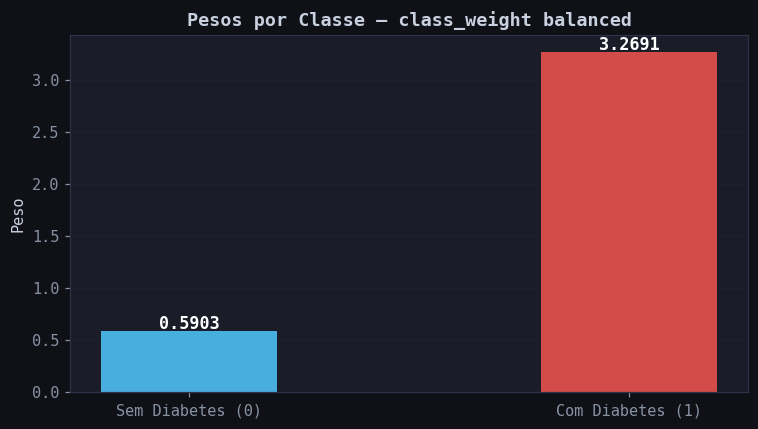

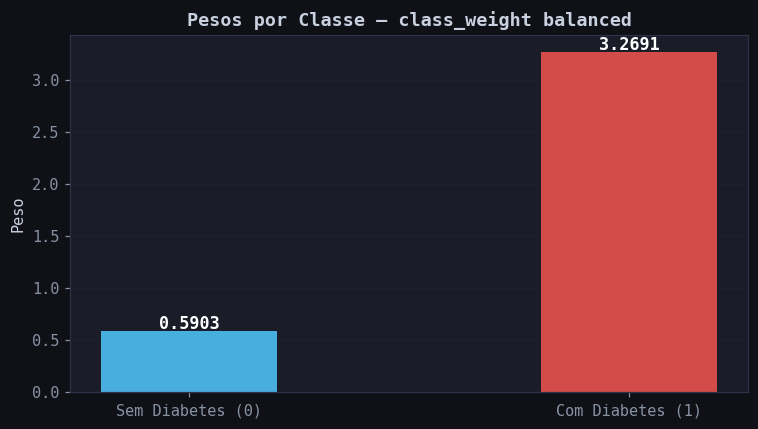

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calcula pesos proporcionais à frequência inversa de cada classe
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: pesos[0], 1: pesos[1]}

print('Pesos calculados (class_weight):')
print(f'  Classe 0 (sem diabetes): {pesos[0]:.4f}')
print(f'  Classe 1 (com diabetes): {pesos[1]:.4f}')
print(f'  Razão peso 1/peso 0    : {pesos[1]/pesos[0]:.2f}x')
print(f'\n→ Erros na classe 1 serão penalizados {pesos[1]/pesos[0]:.1f}x mais que na classe 0')

# Visualização dos pesos
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Sem Diabetes (0)', 'Com Diabetes (1)'], pesos,
              color=CORES, width=0.4, edgecolor='none', alpha=0.88)
for bar, v in zip(bars, pesos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.4f}', ha='center', fontweight='bold', color='white', fontsize=11)
ax.set_title('Pesos por Classe — class_weight balanced', fontsize=12, fontweight='bold')
ax.set_ylabel('Peso')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

O desbalanceamento foi tratado com class_weight='balanced', atribuindo maior peso à classe diabética.
Erros na classe positiva passam a ter impacto 5,54x maior no treinamento.
Isso força o modelo a aprender melhor os padrões da minoria.
A abordagem evita dados sintéticos e preserva a distribuição original.
É mais adequada que SMOTE para variáveis binárias nesse contexto.
O teste mantém proporção real (~86/14), garantindo avaliação fiel.

## Verificação Final da Qualidade

In [ ]:
# Confirmar ausência de nulos e distribuição de features
X_train_df = pd.DataFrame(X_train_proc, columns=FEATURES)

print('Nulos após processamento:', X_train_df.isnull().sum().sum())
print('\nEstatísticas pós-escalonamento (treino):')
X_train_df.describe().round(3)

Nulos após processamento: 0

Estatísticas pós-escalonamento (treino):


,pressao_alta,colesterol_alto,checou_colesterol,imc,fumante,avc,doenca_cardiaca,atividade_fisica,consume_frutas,consume_vegetais,...,sexo,faixa_etaria,escolaridade,renda,imc_categoria,n_fatores_risco,idade_x_saude_geral,score_saudavel,score_socioeconomico,alto_risco_combinado
count,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,...,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000,183579.000
mean,0.454,0.441,-0.040,0.197,0.465,0.044,0.103,-0.266,-0.388,-0.206,...,0.438,0.021,-0.010,-0.036,0.117,0.204,0.075,-0.384,-0.031,0.109
std,0.498,0.497,0.197,0.770,0.499,0.206,0.304,0.442,0.487,0.404,...,0.496,0.773,0.495,0.697,0.517,0.569,0.668,1.082,0.663,0.312
min,0.000,0.000,-1.000,-1.125,0.000,0.000,0.000,-1.000,-1.000,-1.000,...,0.000,-1.750,-1.500,-1.667,-1.000,-0.500,-0.947,-3.000,-1.750,0.000
25%,0.000,0.000,0.000,-0.375,0.000,0.000,0.000,-1.000,-1.000,0.000,...,0.000,-0.500,-0.500,-0.333,-0.500,-0.500,-0.474,-1.000,-0.500,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,1.000,0.000,0.625,1.000,0.000,0.000,0.000,0.000,0.000,...,1.000,0.500,0.500,0.667,0.500,0.500,0.526,0.000,0.500,0.000
max,1.000,1.000,0.000,2.875,1.000,1.000,1.000,0.000,0.000,0.000,...,1.000,1.250,0.500,0.667,1.000,1.500,1.842,1.000,0.750,1.000


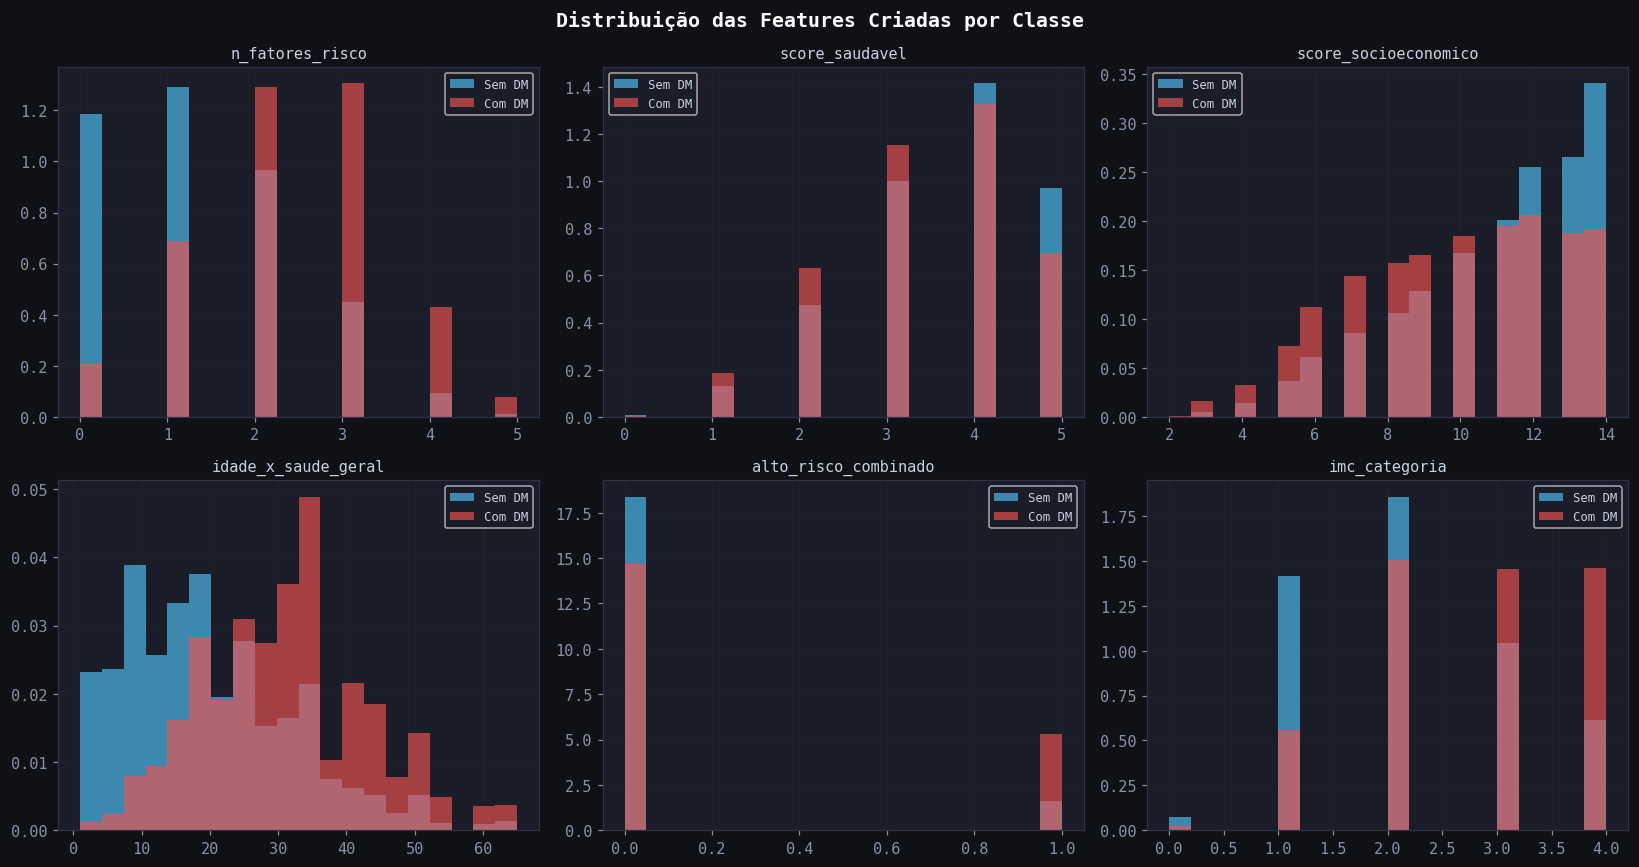

In [ ]:
# Distribuição das novas features no dataset processado
novas_features = ['n_fatores_risco', 'score_saudavel', 'score_socioeconomico',
                  'idade_x_saude_geral', 'alto_risco_combinado', 'imc_categoria']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuição das Features Criadas por Classe',
             fontsize=13, fontweight='bold', color='white')

for ax, feat in zip(axes.flatten(), novas_features):
    for label, cor in zip([0, 1], CORES):
        subset = df[df['diabetes'] == label][feat]
        ax.hist(subset, bins=20, alpha=0.65, color=cor, density=True,
                edgecolor='none',
                label='Sem DM' if label == 0 else 'Com DM')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

A validação final confirma a integridade do pipeline, sem valores nulos no treino.
O escalonamento via RobustScaler gerou distribuições com médias ~0 e desvios consistentes.
As features criadas demonstram bom poder discriminativo.
n_fatores_risco e alto_risco_combinado apresentam maior separação entre classes.
score_saudavel confirma efeito protetor agregado, com inversão clara entre grupos.
score_socioeconomico mostra padrão gradual, enquanto idade_x_saude_geral captura bem a interação.

## Exportação dos Artefatos
Todos os artefatos necessários para a etapa de modelagem são salvos em `./artefatos/`.

In [ ]:
os.makedirs('artefatos', exist_ok=True)

# Pipeline de pré-processamento
joblib.dump(pipeline_preprocessamento, 'artefatos/pipeline_preprocessamento.pkl')

# Conjuntos de dados
np.save('artefatos/X_train.npy', X_train_proc)
np.save('artefatos/X_test.npy',  X_test_proc)
np.save('artefatos/y_train.npy', y_train.values)
np.save('artefatos/y_test.npy',  y_test.values)

# Pesos das classes e nomes das features
joblib.dump(class_weight_dict, 'artefatos/class_weight.pkl')
joblib.dump(FEATURES,          'artefatos/features.pkl')
joblib.dump(MAPA_COLUNAS,      'artefatos/mapa_colunas.pkl')

# Dataset completo processado (sem split)
df.to_parquet('artefatos/dataset_processado.parquet', index=False)

print('✅ Artefatos exportados em ./artefatos/')
print('\n📁 artefatos/')
for f in sorted(os.listdir('artefatos')):
    size = os.path.getsize(f'artefatos/{f}') / 1024
    print(f'   ├── {f:<45} {size:>7.1f} KB')

✅ Artefatos exportados em ./artefatos/

📁 artefatos/
   ├── X_test.npy                                     9681.1 KB
   ├── X_train.npy                                   38723.8 KB
   ├── class_weight.pkl                                  0.1 KB
   ├── dataset_processado.parquet                     1767.5 KB
   ├── features.pkl                                      0.5 KB
   ├── mapa_colunas.pkl                                  0.6 KB
   ├── pipeline_preprocessamento.pkl                     4.7 KB
   ├── y_test.npy                                      358.7 KB
   ├── y_train.npy                                    1434.3 KB
